In [7]:
# Install essential packages
!pip install pandas scikit-learn matplotlib seaborn xgboost comet_ml


In [8]:
import pandas as pd
import numpy as np

# Load CSV file
df = pd.read_csv('D42-WaterSupply_Raipur_1_1.csv')

# Explore raw columns
print(df.head())
print(df.info())


  City Name  Zone Name                       Ward name  Ward No.  \
0    RAIPUR          3          Maharshi Valmiki Ward         28   
1    RAIPUR          3                   Kalimata Ward        30   
2    RAIPUR          3              Shankar Nagar Ward        31   
3    RAIPUR          3  Shahid Veer Narayan Singh Ward        32   
4    RAIPUR          3       Lal Bahudur Shashtri Ward        33   

   Water supply capacity (litres/day)  \
0                           2758000.0   
1                            815040.0   
2                           1393360.0   
3                            894480.0   
4                            867760.0   

   Water usage or Domestic Water Consumption (litres/day)  \
0                                          2407680.0        
1                                           684720.0        
2                                          1215360.0        
3                                           727920.0        
4                                      

In [15]:
# Replace 'NA' or similar missing value markers with np.nan
df.replace('NA', np.nan, inplace=True)

# Drop rows with missing target values
df.dropna(subset=['Water usage or Domestic Water Consumption (litres/day)'], inplace=True)

# Fill any other missing numeric values with column means
df.fillna(df.mean(numeric_only=True), inplace=True)


In [16]:
# Encode categorical columns if present (e.g., Ward name, Zone Name)
for col in ['Zone Name', 'Ward name']:
    if df[col].dtype == 'object':
        df[col] = df[col].astype('category').cat.codes


In [20]:
from sklearn.preprocessing import StandardScaler

features = ['Ward No.', 'Water usage or Domestic Water Consumption (litres/day)', 'Zone Name', 'Ward name']
X = df[features]
y = df['Water usage or Domestic Water Consumption (litres/day)']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [21]:
from sklearn.model_selection import train_test_split

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42)
}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "MSE": mse, "R2": r2}

    experiment.log_metrics({"mae": mae, "mse": mse, "r2": r2}, prefix=name)


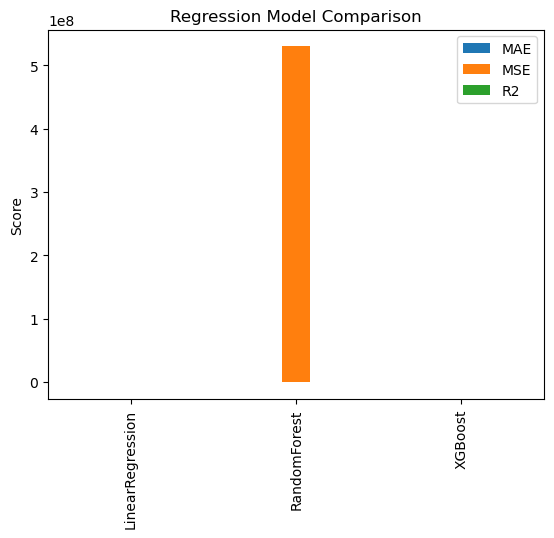

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot metrics
metrics_df = pd.DataFrame(results).T
metrics_df.plot(kind='bar')
plt.title("Regression Model Comparison")
plt.ylabel("Score")
plt.show()


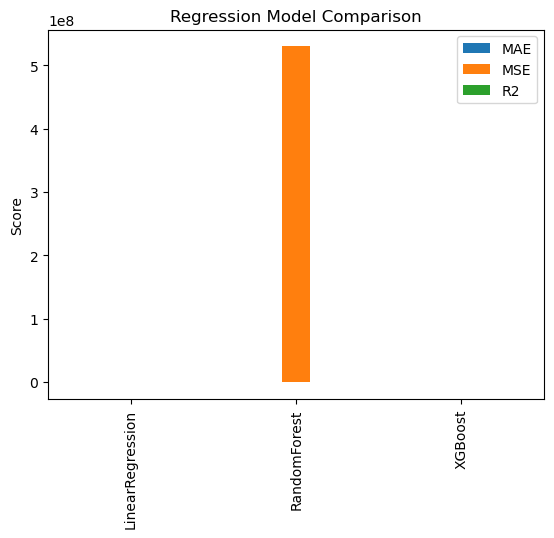

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot metrics
metrics_df = pd.DataFrame(results).T
metrics_df.plot(kind='bar')
plt.title("Regression Model Comparison")
plt.ylabel("Score")
plt.show()


In [37]:
X_new = pd.DataFrame([{
    'Ward No.': 30,
    'Water usage or Domestic Water Consumption (litres/day)': 800000,
    'Zone Name': 3,   # encoded integer consistent with training
    'Ward name': 12   # encoded integer consistent with training
}], columns=feature_cols)

NameError: name 'feature_cols' is not defined

In [30]:
import joblib

best_model_name = metrics_df['R2'].idxmax()
best_model = models[best_model_name]
joblib.dump(best_model, 'best_water_model.pkl')

# Log model file to Comet
experiment.log_model("best_water_model", "best_water_model.pkl")


In [31]:
# Load for prediction
loaded_model = joblib.load('best_water_model.pkl')
y_new = loaded_model.predict(X_new) # Use for new data


NameError: name 'X_new' is not defined

In [33]:
import pandas as pd
import joblib

# Load model (and scaler if saved)
loaded_model = joblib.load("best_water_consumption_model.pkl")  # adjust filename if needed
try:
    scaler = joblib.load("water_features_scaler.pkl")
except FileNotFoundError:
    scaler = None

# Define the new sample(s) with the SAME feature columns and order as training
feature_cols = ['Ward No.', 'Water usage or Domestic Water Consumption (litres/day)', 'Zone Name', 'Ward name']
X_new = pd.DataFrame([{
    'Ward No.': 30,
    'Water supply capacity litresday': 800000,
    'Zone Name': 3,   # encoded integer consistent with training
    'Ward name': 12   # encoded integer consistent with training
}], columns=feature_cols)

# Apply the same scaler if used
if scaler is not None:
    X_new_transformed = scaler.transform(X_new)
else:
    X_new_transformed = X_new.values

# Predict
y_new = loaded_model.predict(X_new_transformed)
print(f"Predicted daily water consumption (litres): {float(y_new[0]):.2f}")


FileNotFoundError: [Errno 2] No such file or directory: 'best_water_consumption_model.pkl'